<a href="https://colab.research.google.com/github/stvngo/Pivotal-Token-Representation-Learning/blob/main/notebooks/steering_random_control.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Steering random-direction control

Null-hypothesis follow-up to `steering_gsm8k_colab.ipynb`. We ask: **does the specific pivotal direction matter, or would any perturbation of comparable norm produce the same accuracy shift?**

Plan
- Load the layer-14 pivotal probe (centroid-diff vector).
- Generate 3 random Gaussian control vectors in 1024 dims, each rescaled to match the probe's norm, with distinct seeds 101/102/103 so we can report mean + std of the null effect.
- Run paired GSM8K eval on 100 examples: base, pivotal at factor 1.2, each random at factor 1.2 (plus factor=0 ablation and factor=-1 anti arms).
- Compare pivotal vs random-mean±std, and count overlapping flipped examples.


## 1. Install dependencies

In [1]:
# Run once per runtime. Safe to skip if already installed.
%pip install -q "transformers>=4.44" datasets accelerate matplotlib seaborn scikit-learn tqdm pandas


## 2. Imports, seeding, device

In [2]:
import json
import os
import random
import re
import sys
import time
import zipfile
from pathlib import Path

import numpy as np
import torch
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    DEVICE = "cuda"
    DTYPE = torch.bfloat16
elif getattr(torch.backends, "mps", None) and torch.backends.mps.is_available():
    DEVICE = "mps"
    DTYPE = torch.float32
else:
    DEVICE = "cpu"
    DTYPE = torch.float32

RUN_TAG = "random_control"
RESULTS_DIR = Path("nb_results") / RUN_TAG
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"device={DEVICE} dtype={DTYPE} run_tag={RUN_TAG}")
print(f"results -> {RESULTS_DIR.resolve()}")


device=cuda dtype=torch.bfloat16 run_tag=random_control
results -> /content/nb_results/random_control


## 3. Experiment configuration

In [3]:
LAYER = 14
FACTORS = [1.2, 0.0, -1.0]
MAX_EXAMPLES = 100
MAX_NEW_TOKENS = 256
TEMPERATURE = 0.6
TOP_P = 0.9
RANDOM_SEEDS = [101, 102, 103]
FORCE_RERUN = False


## 4. Load the pivotal probe

In [4]:
# Probe location.  Fallback order: local repo -> GitHub raw -> manual upload.
LOCAL_PROBE_DIR = Path("artifacts/cached3/sklearn/steering_configs")
PROBE_RAW_URL_BASE = (
    "https://raw.githubusercontent.com/"
    "stvngo/Pivotal-Token-Representation-Learning/"
    "main/artifacts/cached3/sklearn/steering_configs/"
)


In [5]:
import urllib.request


def load_probe(layer: int, local_dir: Path = LOCAL_PROBE_DIR):
    cfg_name = f"steering_layer{layer}.json"
    vec_name = f"steering_layer{layer}_vector.npy"
    cfg_path = local_dir / cfg_name
    vec_path = local_dir / vec_name
    if not (cfg_path.exists() and vec_path.exists()):
        dest = RESULTS_DIR / "probes"
        dest.mkdir(parents=True, exist_ok=True)
        try:
            urllib.request.urlretrieve(PROBE_RAW_URL_BASE + cfg_name, dest / cfg_name)
            urllib.request.urlretrieve(PROBE_RAW_URL_BASE + vec_name, dest / vec_name)
            cfg_path, vec_path = dest / cfg_name, dest / vec_name
        except Exception as exc:
            raise RuntimeError(
                f"Could not locate steering probe for layer {layer}. "
                f"Either clone the repo, fix PROBE_RAW_URL_BASE, or upload the files. ({exc})"
            ) from exc
    cfg = json.loads(cfg_path.read_text())
    vec = np.load(vec_path).astype(np.float32)
    return cfg, vec, cfg_path, vec_path


In [6]:
# --- Google Colab: upload your own probe --------------------------------
# Uncomment if the automatic fallback above fails.
#
# from google.colab import files
# uploaded = files.upload()
# print('Uploaded:', list(uploaded.keys()))


In [7]:
steering_cfg, steering_vector, cfg_path, vec_path = load_probe(LAYER)
_vec_tensor = torch.from_numpy(steering_vector).to(torch.float32)
pivotal_norm = float(_vec_tensor.norm().item())
print(f"Probe: layer={steering_cfg['layer']} norm={pivotal_norm:.4f} hidden_dim={steering_cfg['hidden_dim']}")


Probe: layer=14 norm=9.5937 hidden_dim=1024


## 5. Build random control vectors (norm-matched)

In [8]:
random_vecs = {}
for s in RANDOM_SEEDS:
    g = torch.Generator().manual_seed(s)
    r = torch.randn(steering_cfg["hidden_dim"], generator=g, dtype=torch.float32)
    r = r * (pivotal_norm / r.norm().item())
    random_vecs[s] = r
    cos = float(torch.nn.functional.cosine_similarity(r, _vec_tensor, dim=0))
    print(f"random seed={s}: norm={r.norm().item():.4f} cos(pivotal)={cos:+.4f}")


random seed=101: norm=9.5937 cos(pivotal)=+0.0547
random seed=102: norm=9.5937 cos(pivotal)=+0.0550
random seed=103: norm=9.5937 cos(pivotal)=+0.0045


## 6. Load Qwen3-0.6B

In [9]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_NAME = "Qwen/Qwen3-0.6B"

_t0 = time.time()
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=DTYPE,
    trust_remote_code=True,
    low_cpu_mem_usage=True,
).to(DEVICE)
model.eval()
if tokenizer.pad_token_id is None:
    tokenizer.pad_token_id = tokenizer.eos_token_id
print(
    f"Loaded {MODEL_NAME} on {DEVICE} ({DTYPE}) "
    f"in {time.time() - _t0:.1f}s | hidden_size={model.config.hidden_size} "
    f"layers={model.config.num_hidden_layers}"
)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie model.embed_tokens.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Loaded Qwen/Qwen3-0.6B on cuda (torch.bfloat16) in 14.7s | hidden_size=1024 layers=28


In [10]:
assert steering_vector.shape[0] == model.config.hidden_size


In [ ]:
# Convention check (Issue #2 in docs/issues.md): the forward-hook output of
# `_get_decoder_layer(model, L)` must equal `outputs.hidden_states[L]`. If
# this asserts, the off-by-one fix is in effect and every steering hook below
# modifies the same residual tensor the layer-L probe was trained on.
import torch as _torch  # local alias avoids polluting the notebook namespace

def _convention_check(_model, _layer: int) -> bool:
    captured = {}

    def _cap(_m, _i, _out):
        h = _out[0] if isinstance(_out, tuple) else _out
        captured["pre"] = h.detach()
        return _out

    target = _get_decoder_layer(_model, _layer)
    h = target.register_forward_hook(_cap)
    try:
        _device = next(_model.parameters()).device
        ids = _torch.tensor([[1, 2, 3]], device=_device)
        with _torch.no_grad():
            outs = _model(input_ids=ids, output_hidden_states=True)
    finally:
        h.remove()
    expected = outs.hidden_states[_layer]
    if captured.get("pre") is None:
        return False
    if captured["pre"].shape != expected.shape:
        return False
    return bool(_torch.allclose(captured["pre"], expected, atol=1e-4, rtol=1e-3))

# Pick a layer to check. Notebooks define one of these names.
_probe_layer_for_check = next(
    (v for v in (globals().get("LAYER"), globals().get("PROBE_LAYER"),
                 globals().get("BEST_LAYER"), globals().get("CODELION_LAYER"))
     if isinstance(v, int)),
    14,
)
CONVENTION_CHECK_PASSED = _convention_check(model, _probe_layer_for_check)
print(f"[convention check] hook output == hidden_states[{_probe_layer_for_check}]: "
      f"{CONVENTION_CHECK_PASSED}")
assert CONVENTION_CHECK_PASSED, (
    "Off-by-one regression: hook on layers[L-1] no longer equals "
    "hidden_states[L]. See docs/issues.md Issue #2."
)


## 7. Steering hooks

In [ ]:
import torch
import torch.nn as nn

# Pull the canonical, off-by-one-fixed hook factory from probe_pipeline.steering
# (issues #2 + #7 in docs/issues.md). If the local checkout isn't on sys.path
# (e.g. fresh Colab runtime), fall back to a vendored copy with the same fix.
try:
    from probe_pipeline.steering import _get_decoder_layer, make_hook  # noqa: F401
    print("[hooks] using probe_pipeline.steering (post-Issue-#2/#7 fix)")
except Exception:
    print("[hooks] probe_pipeline not importable, vendoring local fix")

    def _get_decoder_layer(mdl: nn.Module, layer_idx: int) -> nn.Module:
        """Returns the module whose forward-hook output IS hidden_states[layer_idx].

        Post-Issue-#2: layers[layer_idx-1] for layer_idx>=1; embed_tokens for 0.
        """
        if hasattr(mdl, "model") and hasattr(mdl.model, "layers"):
            if layer_idx == 0:
                return mdl.model.embed_tokens
            return mdl.model.layers[layer_idx - 1]
        if hasattr(mdl, "transformer") and hasattr(mdl.transformer, "h"):
            if layer_idx == 0:
                return mdl.transformer.wte
            return mdl.transformer.h[layer_idx - 1]
        raise AttributeError(f"Cannot find decoder layers in {type(mdl)}")

    def make_hook(vector, coef, mode="additive_normalized", position_mask=None):
        if mode not in {"additive_raw", "additive_normalized", "projection"}:
            raise ValueError(f"unknown mode {mode!r}")

        def hook(_module, _args, output):
            hidden = output[0] if isinstance(output, tuple) else output
            v = vector.to(hidden.device).to(hidden.dtype)
            if v.dim() == 1:
                v_full = v.view(1, 1, -1)
            else:
                v_full = v
            if mode == "additive_raw":
                delta = coef * v_full
            elif mode == "additive_normalized":
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                h_norm = hidden.norm(dim=-1, keepdim=True)
                delta = coef * h_norm * v_hat_b
            else:  # projection
                v_hat = v / (v.norm() + 1e-8)
                v_hat_b = v_hat.view(1, 1, -1)
                proj = (hidden * v_hat_b).sum(dim=-1, keepdim=True)
                delta = (coef - 1.0) * proj * v_hat_b
            if position_mask is not None:
                if position_mask.dim() == 1:
                    pm = position_mask.view(1, -1, 1)
                else:
                    pm = position_mask.unsqueeze(-1)
                delta = delta * pm.to(device=hidden.device, dtype=hidden.dtype)
            new_hidden = hidden + delta
            if isinstance(output, tuple):
                return (new_hidden,) + output[1:]
            return new_hidden
        return hook


# ---- thin wrappers that preserve legacy notebook entry points ---------------

# STEERING_MODE controls which convention the *_steering helpers below use.
# Default "additive_normalized" follows the Issue-#7 plan ("canonical default
# for new runs"). Set to "additive_raw" in the notebook BEFORE re-running its
# steered cells if you need the legacy convention for an apples-to-apples
# overlay with the pre-fix runs in artifacts/notebook_runs/REGISTRY.md.
STEERING_MODE = "additive_normalized"


def register_steering(mdl, layer: int, vector, coef: float, mode: str | None = None):
    """Register a single forward hook at ``layer``. ``coef`` is the value we
    pass into ``make_hook``: for ``additive_raw`` that's the legacy
    ``factor - 1.0``; for ``additive_normalized`` it's the unitless per-token
    coefficient on ``||h|| * v_hat``; for ``projection`` it's ``alpha`` (where
    alpha=1 is identity and alpha=0 ablates).
    """
    return [
        _get_decoder_layer(mdl, layer).register_forward_hook(
            make_hook(vector, coef, mode=(mode or STEERING_MODE))
        )
    ]


def register_additive_hooks(mdl, injections, mode: str | None = None):
    """One additive hook per (layer_idx, vector, coef) tuple."""
    handles = []
    for layer_idx, vector, coef in injections:
        handles.append(
            _get_decoder_layer(mdl, layer_idx).register_forward_hook(
                make_hook(vector, coef, mode=(mode or STEERING_MODE))
            )
        )
    return handles


def remove_hooks(handles):
    for h in handles:
        h.remove()


# Probe-weights notebook keeps its own additive/projection helper names so
# section 11/12/15 cells in that notebook don't need rewriting.
def make_additive_hook(vector, alpha):
    return make_hook(vector, alpha, mode="additive_normalized")


def make_projection_hook(unit_vector, alpha):
    return make_hook(unit_vector, alpha, mode="projection")


def register_additive(mdl, layer: int, vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_additive_hook(vector, alpha)
    )]


def register_projection(mdl, layer: int, unit_vector, alpha: float):
    return [_get_decoder_layer(mdl, layer).register_forward_hook(
        make_projection_hook(unit_vector, alpha)
    )]


## 8. Answer parser + metrics

In [12]:
def extract_gsm8k_answer(text: str):
    m = re.search(r"####\s*([+-]?\d+(?:,\d{3})*(?:\.\d+)?)", text)
    if m:
        return m.group(1).replace(",", "").strip()
    nums = re.findall(r"[-+]?\d*\.?\d+", text)
    return nums[-1] if nums else None


def is_correct(pred, gt):
    if pred is None or gt is None:
        return False
    p = pred.strip().replace(",", "")
    g = gt.strip().replace(",", "")
    try:
        return float(p) == float(g)
    except ValueError:
        return p == g


def compute_metrics(results):
    n = len(results)
    if n == 0:
        return {"accuracy": 0.0, "f1": 0.0, "parse_rate": 0.0, "correct": 0, "n": 0}
    correct = sum(1 for r in results if r["correct"])
    parsed = sum(1 for r in results if r["predicted"] is not None)
    tp = correct
    fp = parsed - correct
    fn = n - correct
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "accuracy": correct / n,
        "f1": f1,
        "parse_rate": parsed / n,
        "correct": correct,
        "n": n,
    }


# Inline parser sanity checks (mirror tests/test_answer_extraction.py).
assert extract_gsm8k_answer("#### 42") == "42"
assert extract_gsm8k_answer("He has #### 1,234 apples.") == "1234"
assert extract_gsm8k_answer("The net change is #### -7") == "-7"
assert extract_gsm8k_answer("So the answer is #### 3.50") == "3.50"
assert extract_gsm8k_answer("...so the total is 18 apples.") == "18"
assert extract_gsm8k_answer("") is None
assert is_correct("3.0", "3") is True
assert is_correct("1234", "1,234") is True
assert is_correct(None, "5") is False
print("Parser sanity checks passed.")


Parser sanity checks passed.


## 9. GSM8K test subset

In [13]:
from datasets import load_dataset

_ds_full = load_dataset("openai/gsm8k", "main", split="test")
_rng = np.random.default_rng(SEED)
_indices = sorted(
    _rng.choice(len(_ds_full), size=min(MAX_EXAMPLES, len(_ds_full)), replace=False).tolist()
)
ds_subset = _ds_full.select(_indices)
examples = [
    {"question": row["question"],
     "ground_truth": extract_gsm8k_answer(row["answer"]),
     "answer_full": row["answer"]}
    for row in ds_subset
]
print(f"GSM8K test subset: {len(examples)} examples (seed={SEED})")


README.md: 0.00B [00:00, ?B/s]

main/train-00000-of-00001.parquet:   0%|          | 0.00/2.31M [00:00<?, ?B/s]

main/test-00000-of-00001.parquet:   0%|          | 0.00/419k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7473 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1319 [00:00<?, ? examples/s]

GSM8K test subset: 100 examples (seed=42)


## 10. Generation + eval helpers

In [14]:
def generate_once(prompt: str) -> str:
    enc = tokenizer(prompt, return_tensors="pt", add_special_tokens=True).to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            **enc,
            max_new_tokens=MAX_NEW_TOKENS,
            do_sample=True,
            temperature=TEMPERATURE,
            top_p=TOP_P,
            pad_token_id=tokenizer.pad_token_id,
        )
    return tokenizer.decode(out[0], skip_special_tokens=True)


def _reseed():
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)


def run_eval_with_hooks(label, register_fn, desc_prefix=""):
    '''register_fn(model) -> list of hook handles (or []). Runs paired GSM8K subset.'''
    _reseed()
    handles = register_fn(model) if register_fn is not None else []
    results = []
    try:
        for i, ex in enumerate(tqdm(examples, desc=f"{desc_prefix}{label}")):
            prompt = f"Question: {ex['question']}\n\nLet's think step by step.\n\n"
            text = generate_once(prompt)
            pred = extract_gsm8k_answer(text)
            ok = is_correct(pred, ex["ground_truth"])
            results.append({
                "idx": i,
                "question": ex["question"],
                "ground_truth": ex["ground_truth"],
                "predicted": pred,
                "correct": ok,
                "full_output": text[-1000:],
            })
    finally:
        remove_hooks(handles)
    return results, compute_metrics(results)


def save_run(label, results, metrics, extra_state=None):
    (RESULTS_DIR / f"{label}_results.json").write_text(json.dumps(results, indent=2))
    (RESULTS_DIR / f"{label}_generations.txt").write_text(
        "\n\n====\n\n".join(
            f"[{r['idx']}] gt={r['ground_truth']} pred={r['predicted']} correct={r['correct']}\n{r['full_output']}"
            for r in results
        )
    )
    state = {
        "label": label,
        "model": MODEL_NAME,
        "seed": SEED,
        "max_examples": len(examples),
        "max_new_tokens": MAX_NEW_TOKENS,
        "device": DEVICE,
        "run_tag": RUN_TAG,
        "metrics": metrics,
    }
    if extra_state:
        state.update(extra_state)
    (RESULTS_DIR / f"{label}_state.json").write_text(json.dumps(state, indent=2))
    return state


## 11. Base evaluation

In [15]:
base_cache = RESULTS_DIR / "base_results.json"
if base_cache.exists() and not FORCE_RERUN:
    base_results = json.loads(base_cache.read_text())
    base_metrics = compute_metrics(base_results)
    print("Loaded cached base results.")
else:
    base_results, base_metrics = run_eval_with_hooks("base", register_fn=None)
    save_run("base", base_results, base_metrics)
print(f"base: acc={base_metrics['accuracy']:.3f} f1={base_metrics['f1']:.3f} parse={base_metrics['parse_rate']:.3f}")


base:   0%|          | 0/100 [00:00<?, ?it/s]

base: acc=0.200 f1=0.200 parse=1.000


## 12. Sweep: pivotal + 3 random controls x {1.2, 0.0, -1.0}

10 paired runs total (1 base + 9 steered).

In [16]:
all_runs = {"base": {"results": base_results, "metrics": base_metrics, "arm": "base"}}

def run_vector(label, vec_tensor, factor, arm, extra=None):
    cache = RESULTS_DIR / f"{label}_results.json"
    strength = factor - 1.0
    if cache.exists() and not FORCE_RERUN:
        res = json.loads(cache.read_text())
        met = compute_metrics(res)
        print(f"[cached] {label}: acc={met['accuracy']:.3f} parse={met['parse_rate']:.3f}")
    else:
        def reg(mdl, v=vec_tensor, s=strength):
            return register_steering(mdl, LAYER, v, s)
        res, met = run_eval_with_hooks(label, register_fn=reg)
        state_extra = {"factor": factor, "strength": strength, "arm": arm, "layer": LAYER,
                       "vector_norm": float(vec_tensor.norm().item())}
        if extra:
            state_extra.update(extra)
        save_run(label, res, met, extra_state=state_extra)
        print(f"[done]   {label}: acc={met['accuracy']:.3f} parse={met['parse_rate']:.3f}")
    all_runs[label] = {"results": res, "metrics": met, "arm": arm, "factor": factor}

for factor in FACTORS:
    run_vector(f"pivotal_f{factor}", _vec_tensor, factor, arm="pivotal",
               extra={"vector_type": steering_cfg["vector_type"]})
    for s in RANDOM_SEEDS:
        run_vector(f"random{s}_f{factor}", random_vecs[s], factor, arm=f"random_{s}",
                   extra={"random_seed": s})


pivotal_f1.2:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   pivotal_f1.2: acc=0.270 parse=1.000


random101_f1.2:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   random101_f1.2: acc=0.210 parse=1.000


random102_f1.2:   0%|          | 0/100 [00:00<?, ?it/s]

...

[done]   random101_f-1.0: acc=0.020 parse=1.000


random102_f-1.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   random102_f-1.0: acc=0.090 parse=1.000


random103_f-1.0:   0%|          | 0/100 [00:00<?, ?it/s]

[done]   random103_f-1.0: acc=0.020 parse=0.980


## 13. Aggregate random arm, compare to pivotal

In [17]:
import pandas as pd

rows = []
for name, r in all_runs.items():
    met = r["metrics"]
    rows.append({
        "run": name,
        "arm": r.get("arm", "base"),
        "factor": r.get("factor"),
        "accuracy": met["accuracy"],
        "f1": met["f1"],
        "parse_rate": met["parse_rate"],
    })
df = pd.DataFrame(rows)
df.to_csv(RESULTS_DIR / "summaries.csv", index=False)

summary = {}
for factor in FACTORS:
    piv_acc = all_runs[f"pivotal_f{factor}"]["metrics"]["accuracy"]
    rand_accs = [all_runs[f"random{s}_f{factor}"]["metrics"]["accuracy"] for s in RANDOM_SEEDS]
    summary[factor] = {
        "base_acc": base_metrics["accuracy"],
        "pivotal_acc": piv_acc,
        "random_accs": rand_accs,
        "random_mean": float(np.mean(rand_accs)),
        "random_std": float(np.std(rand_accs)),
        "pivotal_vs_random_mean_pp": float((piv_acc - np.mean(rand_accs)) * 100),
    }
(RESULTS_DIR / "null_summary.json").write_text(json.dumps(summary, indent=2))
df


,run,arm,factor,accuracy,f1,parse_rate
0,base,base,NaN,0.20,0.200000,1.00
1,pivotal_f1.2,pivotal,1.2,0.27,0.270000,1.00
2,random101_f1.2,random_101,1.2,0.21,0.210000,1.00
3,random102_f1.2,random_102,1.2,0.19,0.190000,1.00
4,random103_f1.2,random_103,1.2,0.23,0.230000,1.00
5,pivotal_f0.0,pivotal,0.0,0.25,0.250000,1.00
6,random101_f0.0,random_101,0.0,0.16,0.160000,1.00
7,random102_f0.0,random_102,0.0,0.26,0.260000,1.00
8,random103_f0.0,random_103,0.0,0.13,0.130000,1.00
9,pivotal_f-1.0,pivotal,-1.0,0.18,0.180000,1.00


## 14. Error-bar plot + flip overlap

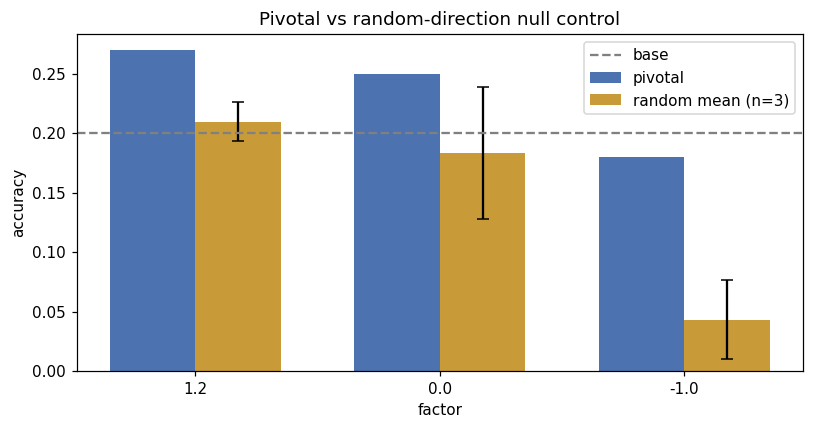

Jaccard(pivotal_flips, random_union_flips) = 0.417


In [18]:
import matplotlib.pyplot as plt
plt.rcParams["figure.dpi"] = 110

fig, ax = plt.subplots(figsize=(7.5, 4))
xs = np.arange(len(FACTORS))
w = 0.35
piv_vals = [summary[f]["pivotal_acc"] for f in FACTORS]
rand_means = [summary[f]["random_mean"] for f in FACTORS]
rand_stds = [summary[f]["random_std"] for f in FACTORS]
ax.bar(xs - w/2, piv_vals, w, label="pivotal", color="#4c72b0")
ax.bar(xs + w/2, rand_means, w, yerr=rand_stds, capsize=4,
       label=f"random mean (n={len(RANDOM_SEEDS)})", color="#c99b38")
ax.axhline(base_metrics["accuracy"], ls="--", color="gray", label="base")
ax.set_xticks(xs); ax.set_xticklabels([str(f) for f in FACTORS])
ax.set_xlabel("factor"); ax.set_ylabel("accuracy")
ax.set_title("Pivotal vs random-direction null control")
ax.legend(); fig.tight_layout()
fig.savefig(RESULTS_DIR / "null_control.png"); plt.show()

# Flip overlap: for factor 1.2, intersect the set of examples each arm flipped.
base_idx_correct = {r["idx"]: r["correct"] for r in base_results}
def flips(res):
    return {r["idx"] for r in res if base_idx_correct.get(r["idx"]) != r["correct"]}

piv_flips = flips(all_runs[f"pivotal_f1.2"]["results"])
rand_flip_sets = [flips(all_runs[f"random{s}_f1.2"]["results"]) for s in RANDOM_SEEDS]
rand_union = set().union(*rand_flip_sets)
overlap = {
    "pivotal_flips": sorted(piv_flips),
    "random_union_flips": sorted(rand_union),
    "jaccard_pivotal_vs_random_union": (len(piv_flips & rand_union) / max(1, len(piv_flips | rand_union))),
    "pivotal_unique": sorted(piv_flips - rand_union),
    "random_unique": sorted(rand_union - piv_flips),
}
(RESULTS_DIR / "flip_overlap.json").write_text(json.dumps(overlap, indent=2))
print("Jaccard(pivotal_flips, random_union_flips) =", round(overlap["jaccard_pivotal_vs_random_union"], 3))


## 15. Bundle and (optionally) download

In [19]:
zip_path = Path(f"nb_results_{RUN_TAG}.zip")
if zip_path.exists():
    zip_path.unlink()
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for p in RESULTS_DIR.rglob("*"):
        if p.is_file():
            zf.write(p, arcname=p.relative_to(RESULTS_DIR.parent))
print(f"Zipped {zip_path} ({zip_path.stat().st_size / 1024:.1f} KB)")

try:
    from google.colab import files  # type: ignore
    files.download(str(zip_path))
except Exception:
    print("Not on Colab — the zip is on the local filesystem.")


Zipped nb_results_random_control.zip (748.4 KB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>